In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [4]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [29]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic["age"] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic["embarked"] = imp_freq.fit_transform(titanic[["embarked"]]).ravel()

# encode
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [36]:
# Decision Tree
model = DecisionTreeClassifier(
    max_depth = 4
)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy:", accuracy_score(y_train, y_pred_train) * 100, "%")
print("Testing accuracy:", accuracy_score(y_test, y_pred_test) * 100, "%")
# classic case of overfitting

Training accuracy: 84.75120385232745 %
Testing accuracy: 82.46268656716418 %


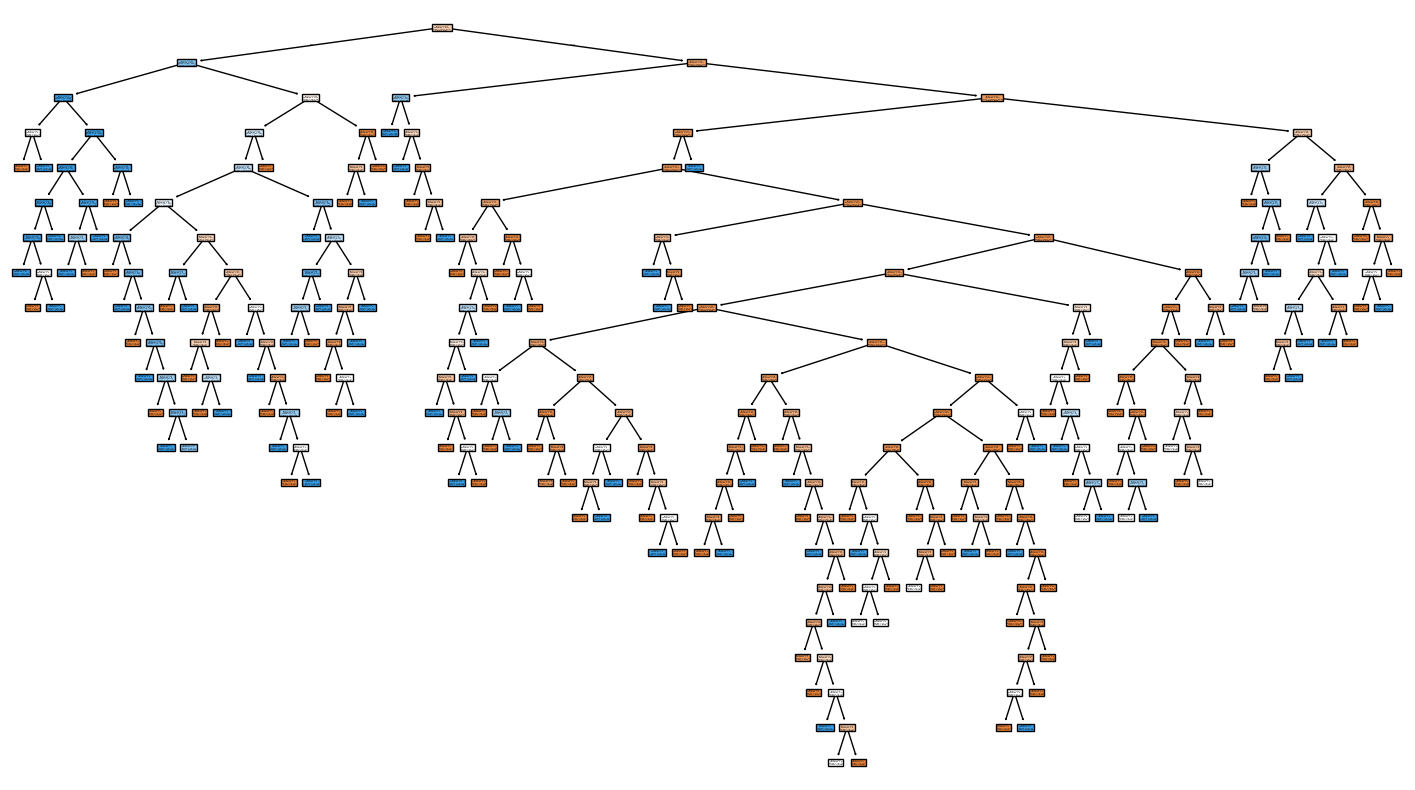

In [31]:
# classic case of overfitting

from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    filled=True, 
    feature_names=X.columns, 
    class_names=["Died", "Survived"])
plt.show()

# Random Forest Classifier 

In [37]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators = 501,
    bootstrap = True, # Default
    oob_score = True,
    max_depth = 4
    
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation 
print("Testing Accuracy", accuracy_score(y_pred,y_test))
print("OOB score", model.oob_score_ * 100 ,"%")

Testing Accuracy 0.8171641791044776
OOB score 82.18298555377207 %


# Bagging Classifier 

In [44]:
# With Decision Trees
from sklearn.ensemble import BaggingClassifier
base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Accuracy :-", accuracy_score(y_pred, y_test))

Accuracy :- 0.7761194029850746


In [45]:
### With logistic Regression 
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression(
    max_iter = 201
)

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Accuracy :-", accuracy_score(y_pred, y_test))

Accuracy :- 0.7947761194029851
